In [14]:
import kaleidocell
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [2]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/08_TICAtlas"
adata = sc.read_h5ad(f"{BASE}/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")
print(adata)


AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference

In [17]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

### explore TICA annotation on GBmap

In [5]:
print("Level 1 — missing annotations:", adata.obs["decoupler_level1_celltype"].isna().sum())
print("Level 2 — missing annotations:", adata.obs["decoupler_level2_celltype"].isna().sum())

print("Level 1 — total cells:", adata.n_obs)
print("Level 1 — annotated cells:", adata.obs["decoupler_level1_celltype"].notna().sum())

Level 1 — missing annotations: 0
Level 2 — missing annotations: 0
Level 1 — total cells: 633710
Level 1 — annotated cells: 633710


In [3]:
scores_l1 = adata.obsm["level1_score_wsum"]
scores_l2 = adata.obsm["level2_score_wsum"]

# Zellen, bei denen ALLE Zelltyp-Scores NaN sind (kein einziger Zelltyp erreicht tmin)
rows_all_nan_l1 = scores_l1.isna().all(axis=1)
rows_all_nan_l2 = scores_l2.isna().all(axis=1)

print(f"Level 1: {rows_all_nan_l1.sum()} Zellen ohne jeglichen Score")
print(f"Level 2: {rows_all_nan_l2.sum()} Zellen ohne jeglichen Score")

# Zellen mit TEILWEISE NaN (manche Zelltypen ok, andere nicht — weniger kritisch,
# da idxmax() das automatisch ignoriert, solange nicht ALLE NaN sind)
rows_any_nan_l1 = scores_l1.isna().any(axis=1)
print(f"Level 1: {rows_any_nan_l1.sum()} Zellen mit mind. einem NaN-Zelltyp-Score")
rows_any_nan_l2 = scores_l2.isna().any(axis=1)
print(f"Level 2: {rows_any_nan_l2.sum()} Zellen mit mind. einem NaN-Zelltyp-Score")

Level 1: 0 Zellen ohne jeglichen Score
Level 2: 0 Zellen ohne jeglichen Score
Level 1: 0 Zellen mit mind. einem NaN-Zelltyp-Score
Level 2: 0 Zellen mit mind. einem NaN-Zelltyp-Score


### Barplot TICA level 1

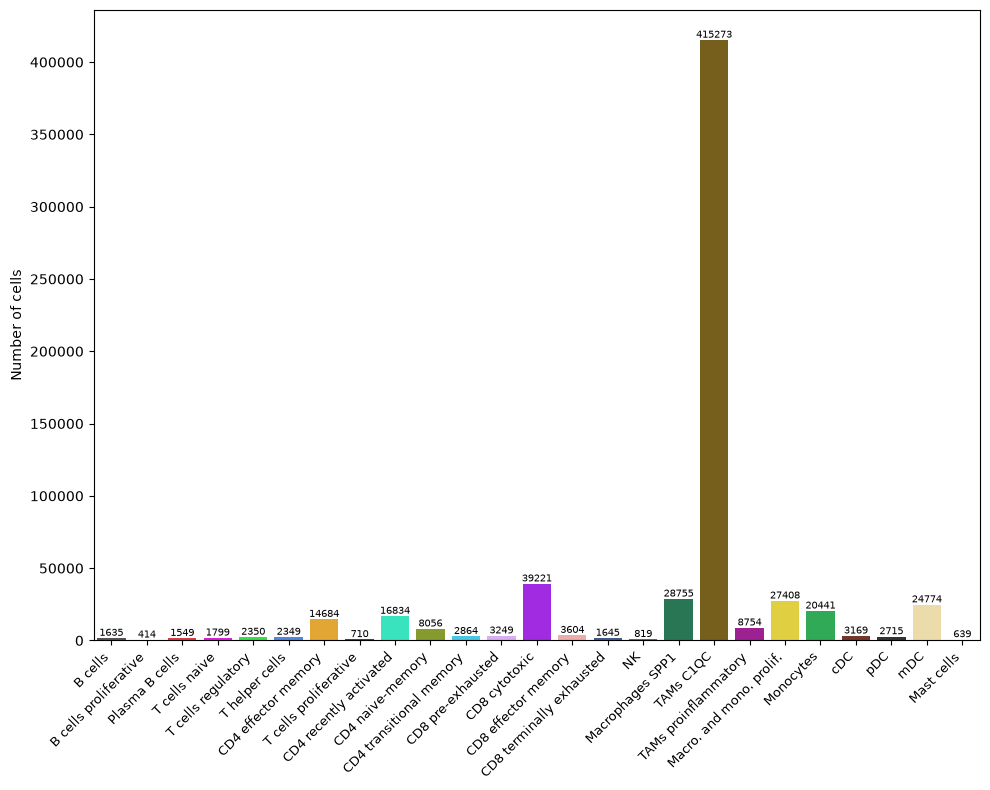

In [7]:
celltype_counts = adata.obs["decoupler_level1_celltype"].value_counts()
celltype_counts = celltype_counts.reindex(celltype_palette.keys())

counts_df = celltype_counts.reset_index()
counts_df.columns = ["celltype", "count"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=counts_df, x="celltype", y="count",
    hue="celltype", palette=celltype_palette,
    order=list(celltype_palette.keys()), legend=False, ax=ax,
)
for i, v in enumerate(celltype_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=7)
ax.set_xticks(range(len(counts_df)))
ax.set_xticklabels(counts_df["celltype"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of cells", fontsize=10)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_05_barplot_celltype_counts.pdf", bbox_inches="tight", dpi=300)

### UMAP TICA Level 1

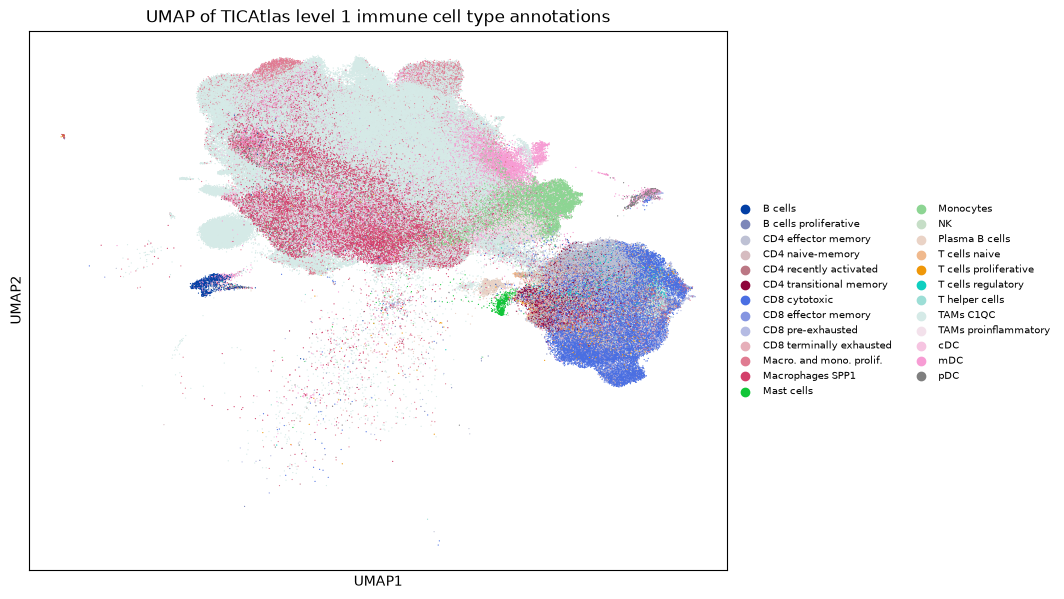

[2026-08-19 08:49:45] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_decoupler_level1.pdf


In [9]:

fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata, color="decoupler_level1_celltype", ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of TICAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
out_umap = os.path.join(OUT_DIR, "08_05_umap_decoupler_level1.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [10]:
adata.obs['decoupler_level1_celltype'].unique().tolist()

cell_type_order = [
    'Macro. and mono. prolif.', 'Monocytes', 'TAMs C1QC', 'Macrophages SPP1',
    'TAMs proinflammatory', 'mDC', 'cDC', 'pDC',
    'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory',
    'CD4 effector memory', 'T helper cells', 'T cells regulatory',
    'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted',
    'T cells naive', 'T cells proliferative', 'NK', 'Mast cells',
    'B cells', 'B cells proliferative', 'Plasma B cells',
]

### UMAP different coloring TICA level 1

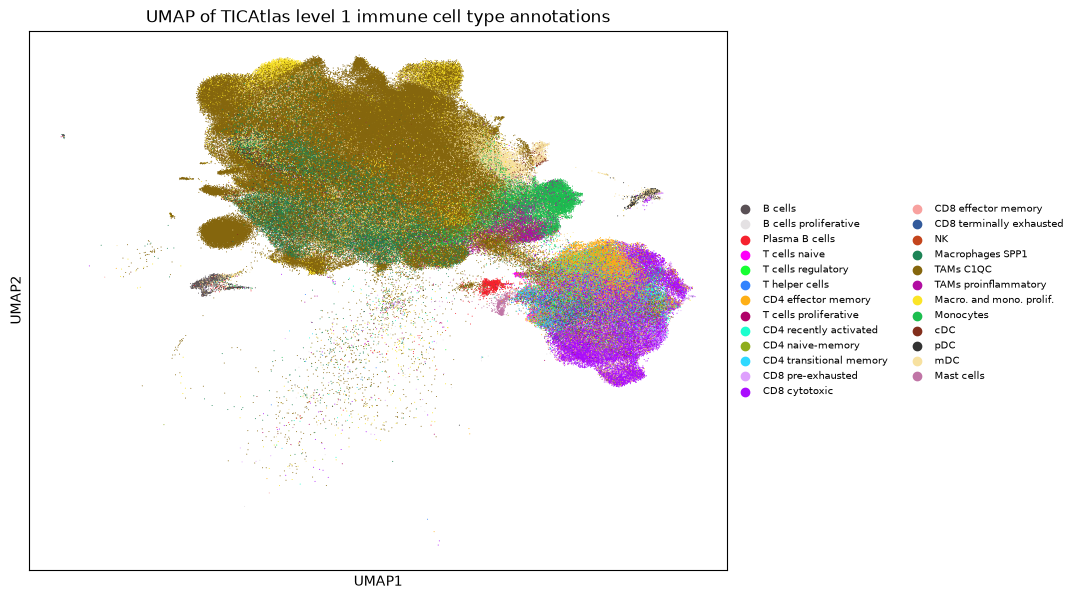

[2026-09-12 09:28:50] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_gb_tica_lvl1.pdf


In [11]:
import colorsys
import matplotlib.colors as mcolors
import numpy as np



fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata, color="decoupler_level1_celltype", ax=ax, show=False, size=2, legend_fontsize=7, palette=celltype_palette, title="UMAP of TICAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
out_umap = os.path.join(OUT_DIR, "08_05_umap_gb_tica_lvl1.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

### calculate UMAP again on GB

In [15]:
kaleidocell.recompute_pca_umap(adata, n_pcs=50, umap_min_dist=0.5, umap_spread=1.0, random_state=42)
print(adata)

PCA recomputed.
UMAP recomputed.
AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', '

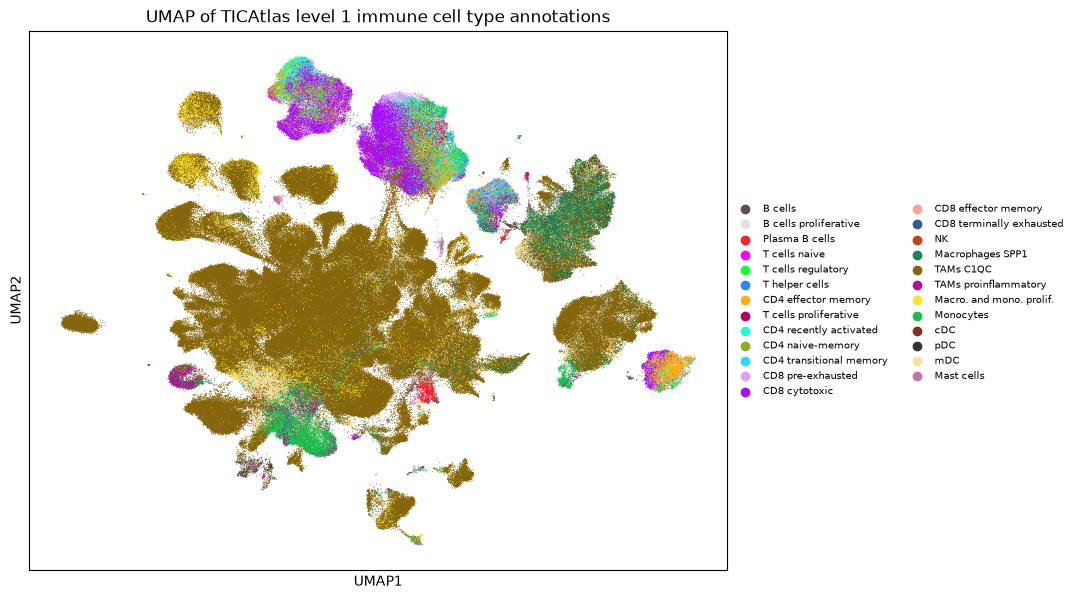

[2026-09-12 16:15:57] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_new_gb_tica_lvl1.pdf


In [16]:


fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata, color="decoupler_level1_celltype", ax=ax, show=False, size=2, legend_fontsize=7, palette=celltype_palette, title="UMAP of TICAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
out_umap = os.path.join(OUT_DIR, "08_05_umap_new_gb_tica_lvl1.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [19]:
import anndata
anndata.settings.allow_write_nullable_strings = True
adata.write("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gb_tica_newUmap.h5ad")

### UMAP grid for each TICA level1 celltype

[2026-08-28 12:43:17] Celltypes (25): ['B cells', 'B cells proliferative', 'CD4 effector memory', 'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted', 'Macro. and mono. prolif.', 'Macrophages SPP1', 'Mast cells', 'Monocytes', 'NK', 'Plasma B cells', 'T cells naive', 'T cells proliferative', 'T cells regulatory', 'T helper cells', 'TAMs C1QC', 'TAMs proinflammatory', 'cDC', 'mDC', 'pDC']
[2026-08-28 12:43:17] Celltypes (25): ['B cells', 'B cells proliferative', 'CD4 effector memory', 'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted', 'Macro. and mono. prolif.', 'Macrophages SPP1', 'Mast cells', 'Monocytes', 'NK', 'Plasma B cells', 'T cells naive', 'T cells proliferative', 'T cells regulatory', 'T helper cells', 'TAMs C1QC', 'TAMs proinflammatory', 'cDC', 'mDC', 'pDC']
[2

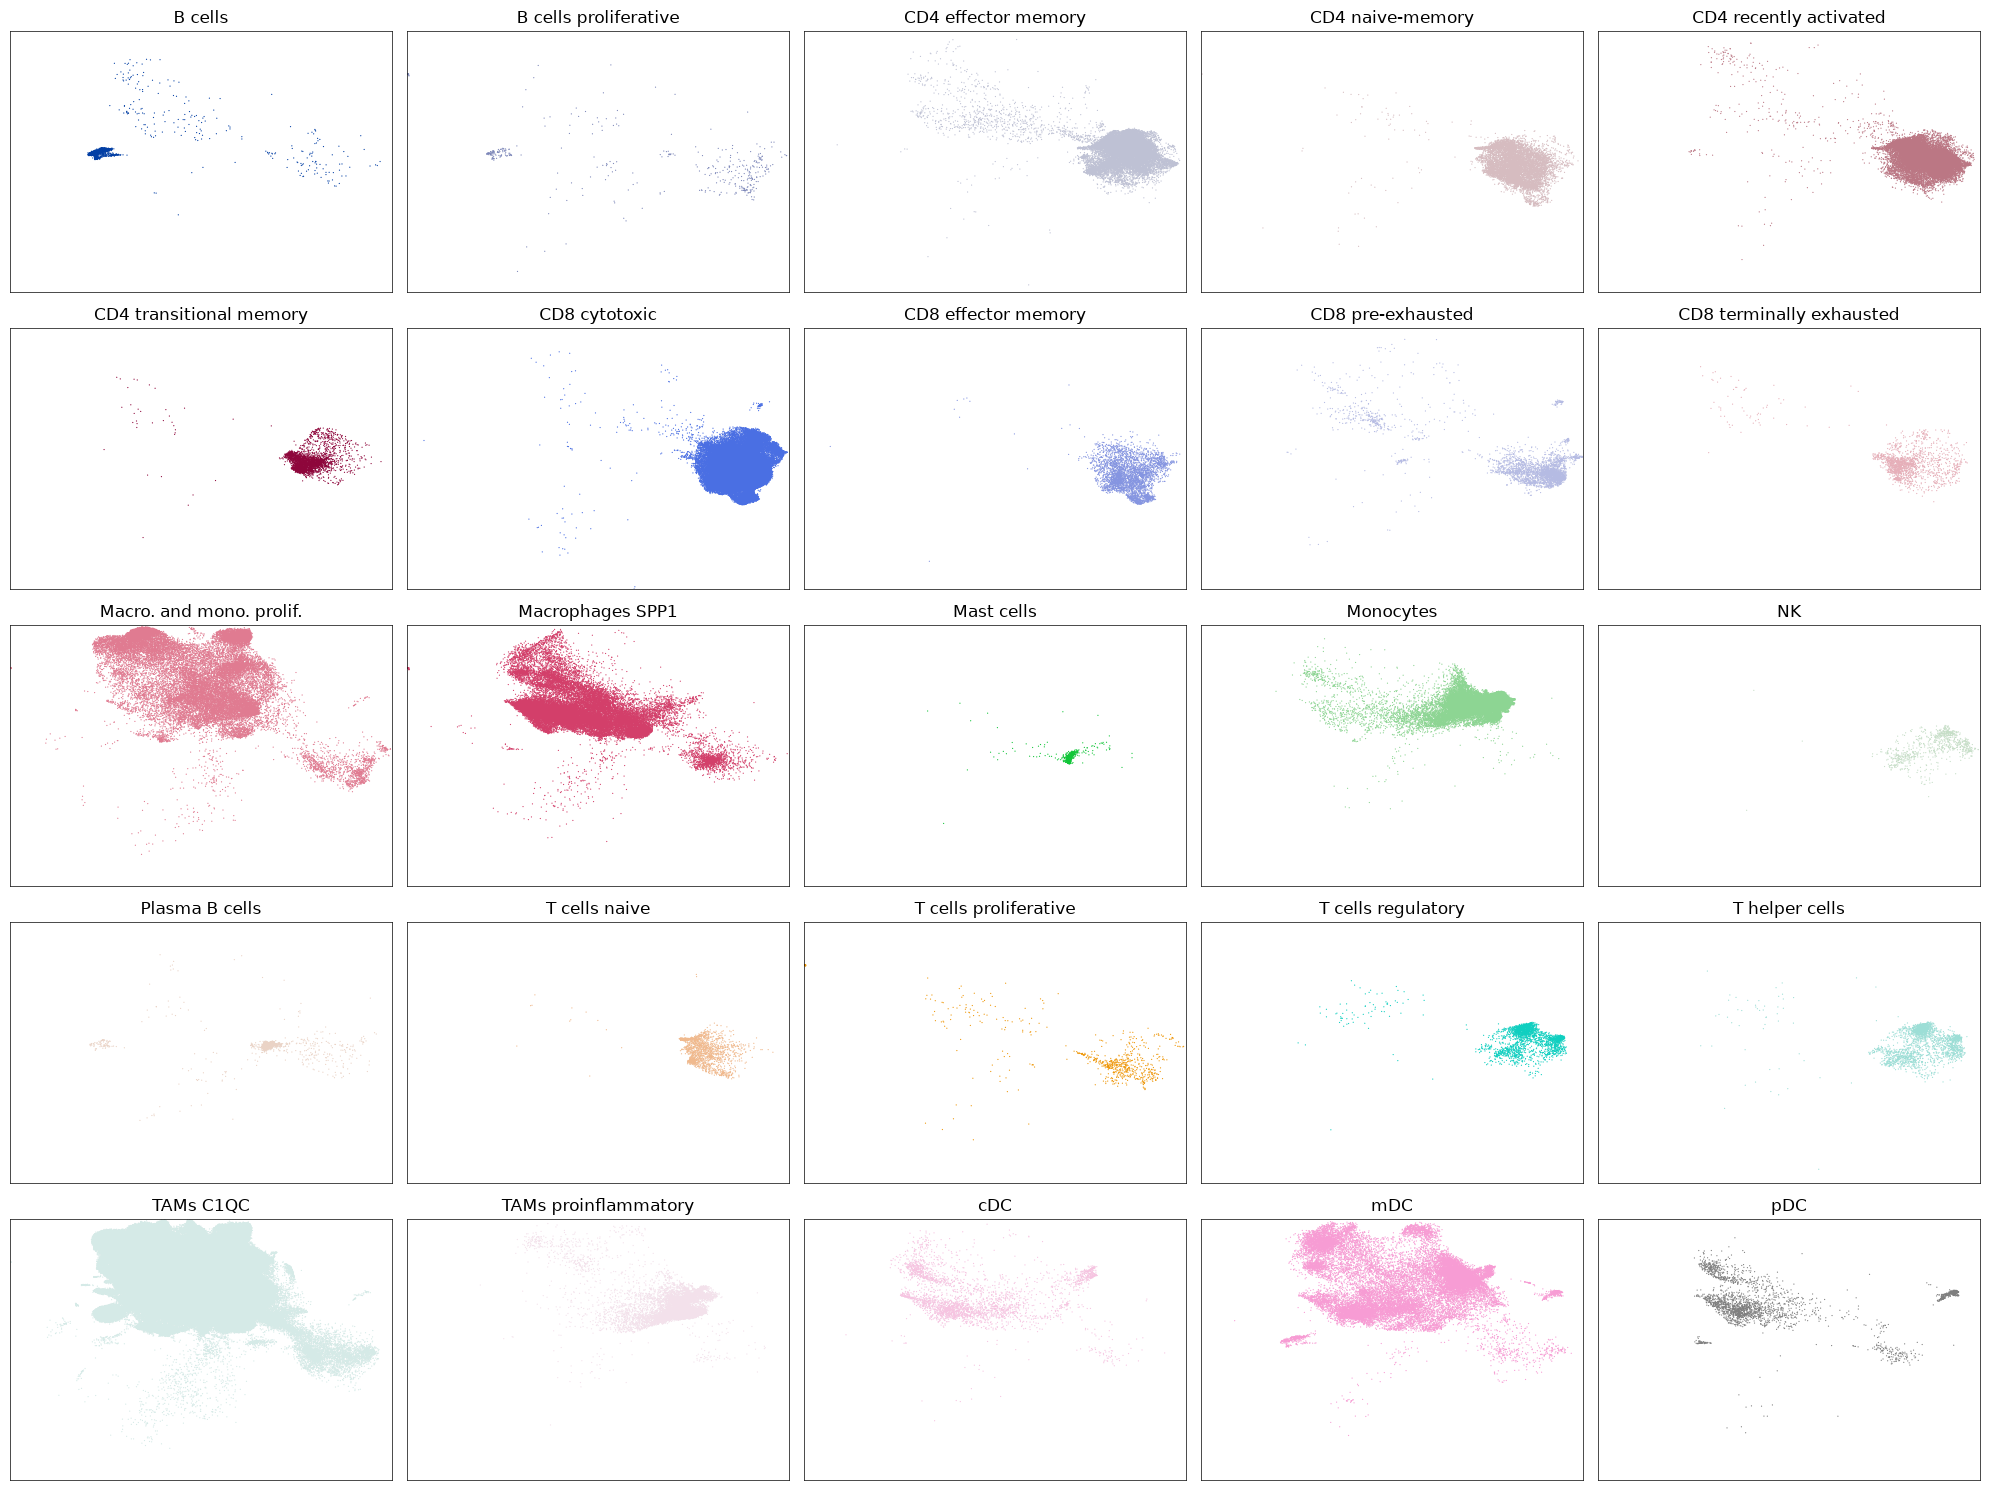

[2026-08-28 12:43:39] Done!


In [25]:
# ── Get celltypes ────────────────────────────────────────────────────────────────────────
celltype_col = "decoupler_level1_celltype"
celltypes = sorted(adata.obs[celltype_col].unique())
n_celltypes = len(celltypes)

checkpoint(f"Celltypes ({n_celltypes}): {celltypes}")

# ── Get celltypes and generate consistent palette ────────────────────────────────────────
celltype_col = "decoupler_level1_celltype"
celltypes = sorted(adata.obs[celltype_col].unique())
n_celltypes = len(celltypes)

checkpoint(f"Celltypes ({n_celltypes}): {celltypes}")

# Generate consistent palette (same as single UMAP plot)
import itertools
from fractions import Fraction
import colorsys
from matplotlib.colors import to_hex

def fracs():
    yield Fraction(0)
    for k in range(20):
        denom = 2**k
        for j in range(1, denom, 2):
            yield Fraction(j, denom)

def hsv_to_rgb(x):
    return colorsys.hsv_to_rgb(*map(float, x))

def rgbs():
    for h in fracs():
        for s in [Fraction(6, 10)]:
            for v in [Fraction(8, 10), Fraction(5, 10)]:
                yield hsv_to_rgb((h, s, v))

palette = [to_hex(c) for c in itertools.islice(rgbs(), n_celltypes)]
checkpoint(f"Generated {len(palette)} colors")

# ── Plot grid ────────────────────────────────────────────────────────────────────────────
# Grid layout: 4 rows × 5 columns = 20 subplots
n_cols = 5
n_rows = (n_celltypes + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

checkpoint(f"Plotting {n_celltypes} celltypes in {n_rows}×{n_cols} grid...")
all_umap = adata.obsm["X_umap"]

xlim = (all_umap[:, 0].min(), all_umap[:, 0].max())
ylim = (all_umap[:, 1].min(), all_umap[:, 1].max())

for i, celltype in enumerate(celltypes):
    ax = axes[i]
    
    # Subset to current celltype
    mask = adata.obs[celltype_col] == celltype
    adata_subset = adata[mask].copy()
    
    # Plot UMAP
    sc.pl.umap(
        adata_subset,
        color=celltype_col,
        ax=ax,
        show=False,
        size=3,
        legend_loc=None,  # no legend in individual plots
        frameon=True,
        title=celltype
    )
    
    # frame for each umap plot
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
  
    
    # squared axis and visible frame
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('auto')  # quadratisch

    for spine_name in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_name].set_visible(True)
        ax.spines[spine_name].set_linewidth(0.5)
        ax.spines[spine_name].set_color('black')

# Hide empty subplots (if any)
for j in range(n_celltypes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


# ── Save ─────────────────────────────────────────────────────────────────────────────────
out_pdf = os.path.join(OUT_DIR, "08_05_umap_tica_level1_grid.pdf")
checkpoint(f"Saving grid to {out_pdf}...")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
checkpoint(f"Saved: {out_pdf}")
plt.show(fig)
plt.close(fig)
checkpoint("Done!")

### UMAP grid: for each celltype of TICA annotation level 1 with others in lightgrey

In [20]:
old_order = [
    'B cells',
    'B cells proliferative',
    'CD4 effector memory',
    'CD4 naive-memory',
    'CD4 recently activated',
    'CD4 transitional memory',
    'CD8 cytotoxic',
    'CD8 effector memory',
    'CD8 pre-exhausted',
    'CD8 terminally exhausted',
    'Macro. and mono. prolif.',
    'Macrophages SPP1',
    'Mast cells',
    'Monocytes',
    'NK',
    'Plasma B cells',
    'T cells naive',
    'T cells proliferative',
    'T cells regulatory',
    'T helper cells',
    'TAMs C1QC',
    'TAMs proinflammatory',
    'cDC',
    'mDC',
    'pDC']

In [21]:
color_list = {
    'Macro. and mono. prolif.': '#ffd88c',
    'Monocytes':                '#e6b350',
    'TAMs C1QC':                '#eb5a3b',
    'Macrophages SPP1':         '#cc7e23',
    'TAMs proinflammatory':     '#ad1010',
    'mDC':                      '#9bf285',
    'cDC':                      '#71d957',
    'pDC':                      '#4dbf30',
    'CD4 naive-memory':         '#faa2cc',
    'CD4 recently activated':   '#e479ac',
    'CD4 transitional memory':  '#ce548f',
    'CD4 effector memory':      '#b83574',
    'T helper cells':           '#a21c5c',
    'T cells regulatory':       '#8c0747',
    'CD8 cytotoxic':            '#df91f2',
    'CD8 effector memory':      '#b558cc',
    'CD8 pre-exhausted':        '#8d2ca6',
    'CD8 terminally exhausted': '#690d80',
    'T cells naive':            '#9dd9f2',
    'T cells proliferative':    '#65b0d0',
    'NK':                       '#378bae',
    'Mast cells':               '#15688c',
    'B cells':                  '#b091f2',
    'B cells proliferative':    '#6e48bf',
    'Plasma B cells':           '#3b158c',
}

palette = dict(zip(old_order, [color_list[ct] for ct in old_order]))

In [22]:
adata.obs["decoupler_level1_celltype"].cat.categories.tolist()


['B cells',
 'B cells proliferative',
 'CD4 effector memory',
 'CD4 naive-memory',
 'CD4 recently activated',
 'CD4 transitional memory',
 'CD8 cytotoxic',
 'CD8 effector memory',
 'CD8 pre-exhausted',
 'CD8 terminally exhausted',
 'Macro. and mono. prolif.',
 'Macrophages SPP1',
 'Mast cells',
 'Monocytes',
 'NK',
 'Plasma B cells',
 'T cells naive',
 'T cells proliferative',
 'T cells regulatory',
 'T helper cells',
 'TAMs C1QC',
 'TAMs proinflammatory',
 'cDC',
 'mDC',
 'pDC']

In [24]:
cats = list(adata.obs["decoupler_level1_celltype"].cat.categories)

# Sanity-Check: sind alle Kategorien in color_list abgedeckt?
missing = set(cats) - set(color_list.keys())
assert not missing, f"Fehlende Farben für: {missing}"

# Vollständige, korrekt geordnete Farbliste in .uns setzen
adata.uns["decoupler_level1_celltype_colors"] = [color_list[c] for c in cats]

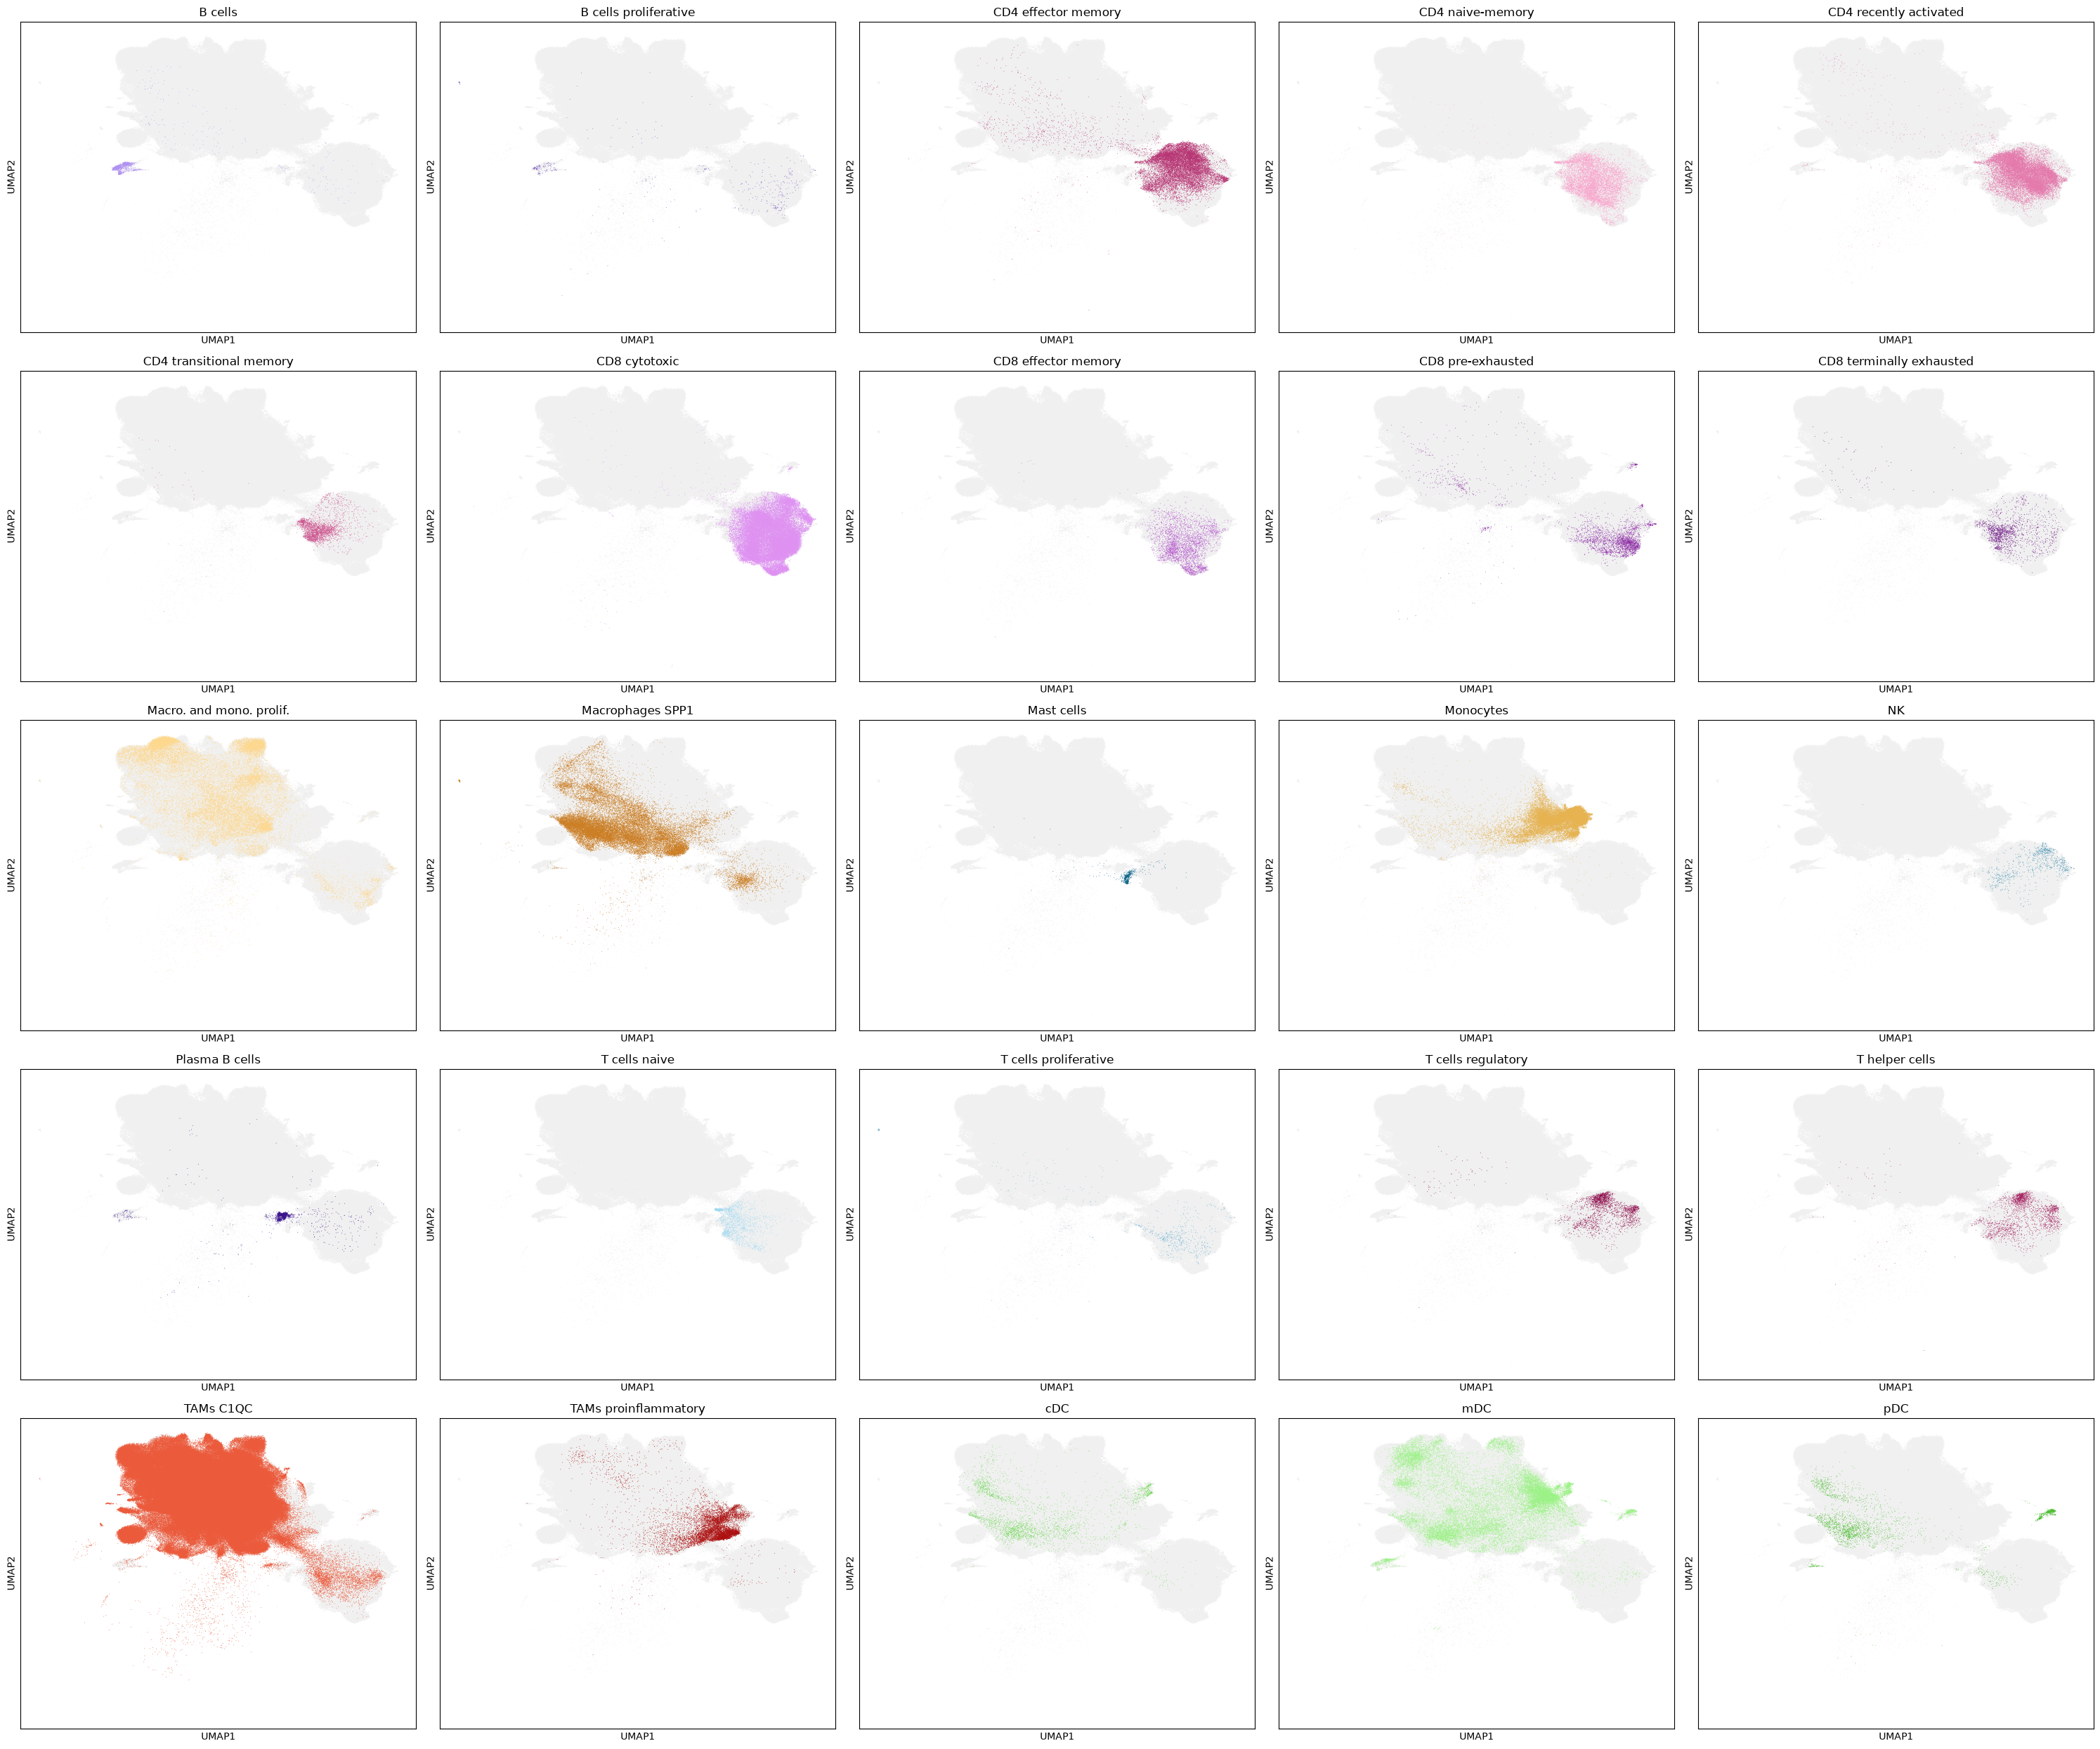

In [26]:

n_cols = 5
n_rows = -(-len(cats) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, ct in enumerate(cats):
    sc.pl.umap(
        adata,
        color="decoupler_level1_celltype",
        groups=[ct],           # nur diesen Zelltyp farbig hervorheben
        na_color="#f0f0f0",    # sehr helles Grau für alle anderen Zellen
        ax=axes[i],
        show=False,
        title=ct,
        size=1.5,
        frameon=True,
        legend_loc=None,       # Legende weglassen, sonst pro Panel überladen
    )
    axes[i].set_rasterized(True)

for j in range(len(cats), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_05_umap_grid_ticalvl1_highlighted.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

### UMAP grid: for each celltype of GBmap_annotation_level_3

[2026-08-28 12:56:06] Celltypes (10): ['B cell', 'CD4/CD8', 'DC', 'Mast', 'Mono', 'NK', 'Neutrophil', 'Plasma B', 'TAM-BDM', 'TAM-MG']
[2026-08-28 12:56:06] Plotting 10 celltypes in 3×4 grid...
[2026-08-28 12:56:13] Saving grid to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_gbmap_level1_grid.pdf...
[2026-08-28 12:56:25] Saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_gbmap_level1_grid.pdf


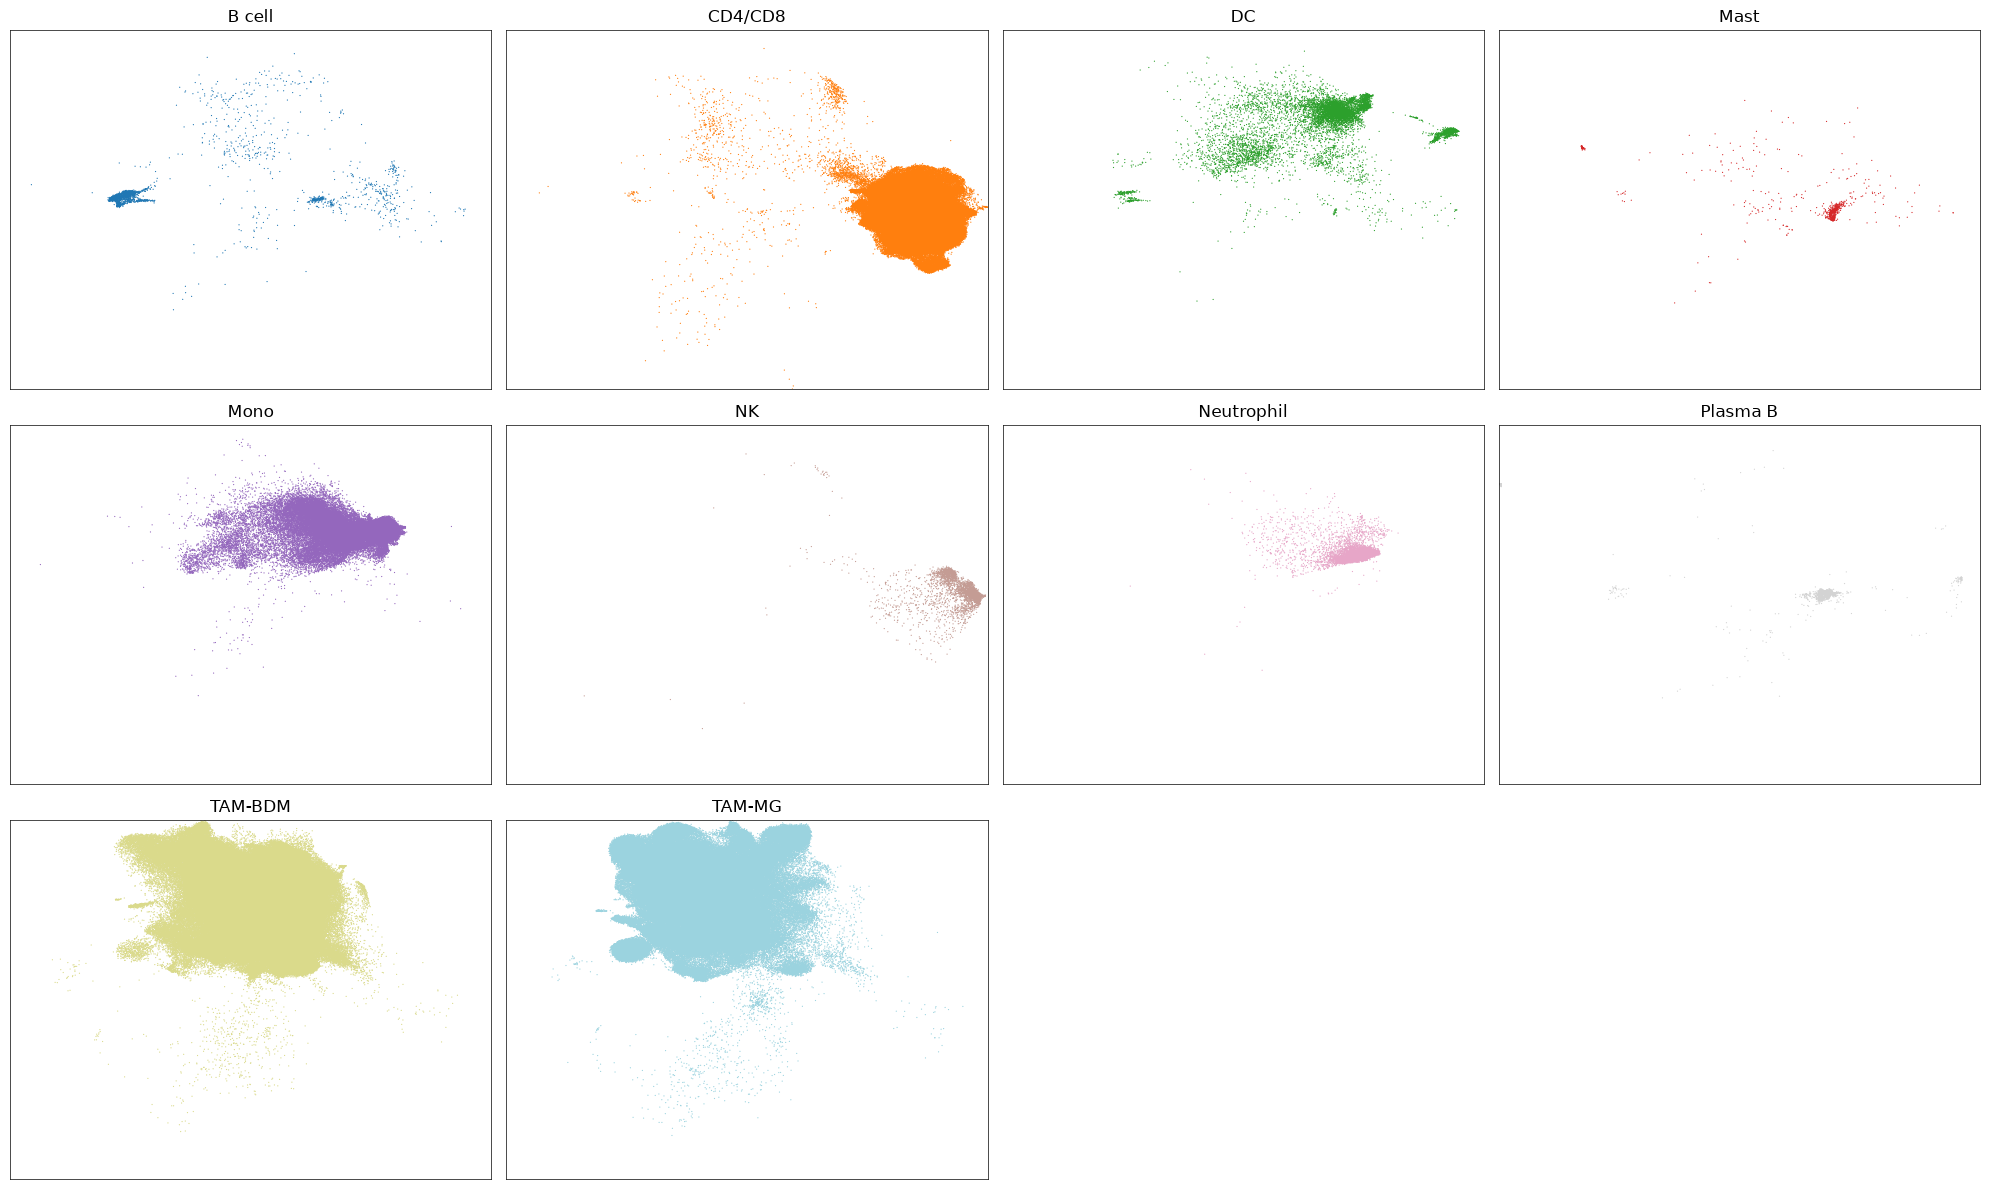

[2026-08-28 12:56:27] Done!


In [29]:
# ── Get celltypes ────────────────────────────────────────────────────────────────────────
celltype_col = "annotation_level_3"
celltypes = sorted(adata.obs[celltype_col].unique())
n_celltypes = len(celltypes)

checkpoint(f"Celltypes ({n_celltypes}): {celltypes}")


# Generate consistent palette (same as single UMAP plot)
import itertools
from fractions import Fraction
import colorsys
from matplotlib.colors import to_hex

# Exact colors from the displayed legend
celltype_colors = {
    "B cell":      "#1f77b4",  # blue
    "CD4/CD8":     "#ff7f0e",  # orange
    "DC":          "#2ca02c",  # green
    "Mast":        "#d62728",  # red
    "Mono":        "#9467bd",  # purple
    "NK":          "#c49c94",  # beige
    "Neutrophil":  "#e7a6c8",  # pink
    "Plasma B":    "#d3d3d3",  # light gray
    "TAM-BDM":     "#dada8b",  # yellow-green
    "TAM-MG":      "#9bd3df",  # light blue
}

# Ensure the annotation names match the dictionary
celltypes = sorted(adata.obs[celltype_col].dropna().unique())

missing_colors = set(celltypes) - set(celltype_colors)
if missing_colors:
    raise ValueError(f"No color defined for: {missing_colors}")
# ── Plot grid ────────────────────────────────────────────────────────────────────────────

n_cols = 4
n_rows = 3  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

checkpoint(f"Plotting {n_celltypes} celltypes in {n_rows}×{n_cols} grid...")
all_umap = adata.obsm["X_umap"]

xlim = (all_umap[:, 0].min(), all_umap[:, 0].max())
ylim = (all_umap[:, 1].min(), all_umap[:, 1].max())

for i, celltype in enumerate(celltypes):
    ax = axes[i]
    
    # Subset to current celltype
    mask = adata.obs[celltype_col] == celltype
    adata_subset = adata[mask].copy()
    
    # Plot UMAP
    sc.pl.umap(
        adata_subset,
        color=celltype_col,
        palette=[celltype_colors[celltype]],
        ax=ax,
        show=False,
        size=3,
        legend_loc=None,  # no legend in individual plots
        frameon=True,
        title=celltype
    )
    
    # frame for each umap plot
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
  
    
    # squared axis and visible frame
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('auto')  # quadratisch

    for spine_name in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_name].set_visible(True)
        ax.spines[spine_name].set_linewidth(0.5)
        ax.spines[spine_name].set_color('black')

# Hide empty subplots (if any)
for j in range(n_celltypes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


# ── Save ─────────────────────────────────────────────────────────────────────────────────
out_pdf = os.path.join(OUT_DIR, "08_05_umap_gbmap_level1_grid.pdf")
checkpoint(f"Saving grid to {out_pdf}...")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
checkpoint(f"Saved: {out_pdf}")
plt.show(fig)
plt.close(fig)
checkpoint("Done!")

## UMAP Level 2

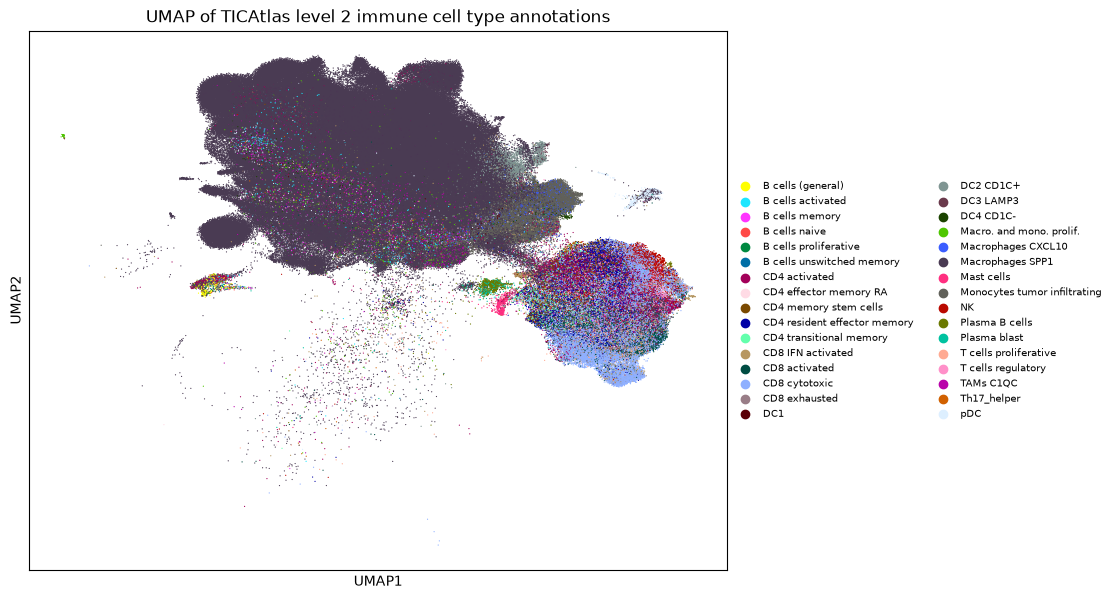

[2026-08-19 10:27:05] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_05_umap_decoupler_level2.pdf


In [14]:

fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata, color="decoupler_level2_celltype", ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of TICAtlas level 2 immune cell type annotations")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_05_umap_decoupler_level2.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)

checkpoint(f"UMAP saved: {out_umap}")